In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 

In [10]:
df = pd.read_csv("Admission_Predict_Ver1.1.csv")
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [11]:
df.shape

(500, 9)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [13]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

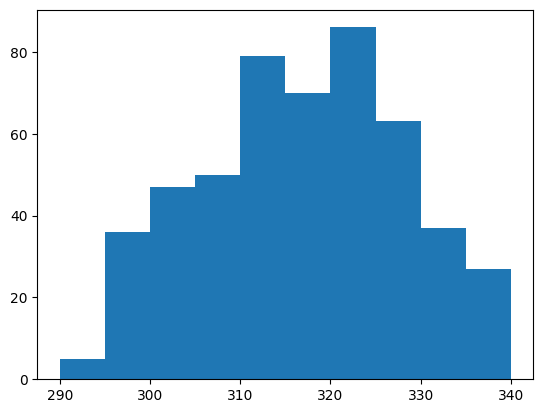

In [ ]:
plt.hist(df['GRE Score'])
plt.show()
#HISTROGRAM GRE SCORE

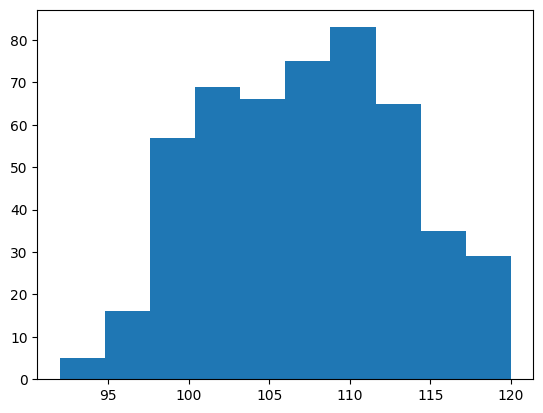

In [ ]:
plt.hist(df['TOEFL Score'])
plt.show()
#HISTOGRAM TOEFL SCORE

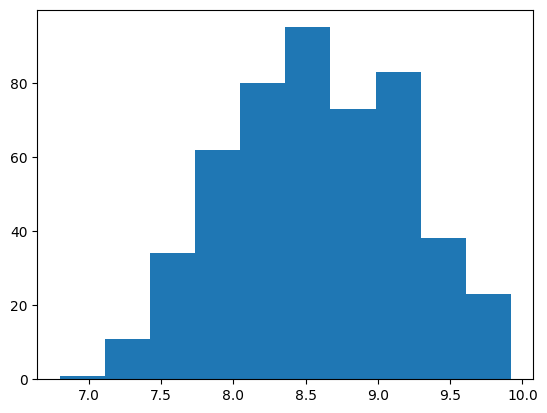

In [16]:
plt.hist(df['CGPA'])
plt.show()
#HISTOGRAM CGPA

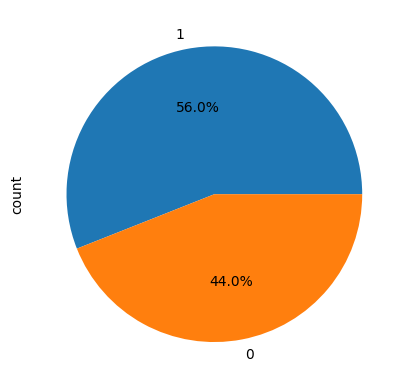

In [17]:
df['Research'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.show()
#PIE CHART RESEARCH

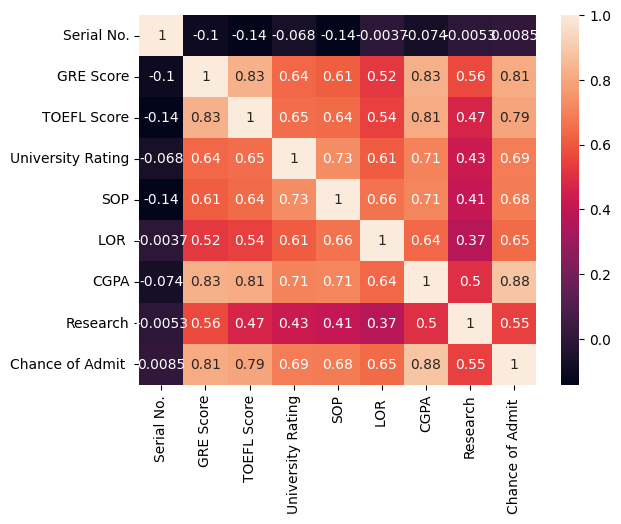

In [18]:
sns.heatmap(df.corr(),annot=True)
plt.show()
#HEATMAP CORRELATION

In [19]:
df.drop(
    'Serial No.',
    axis=1,
    inplace=True
)
#DROP SERIAL NO.(PREPROCESSING)

In [20]:
df['Admission_Status'] = np.where(
    df['Chance of Admit '] >= 0.75,
    1,
    0
)
#BUAT KOLOM BARU ADMISSION STATUS (1: LULUS, 0: TIDAK LULUS) (PREPROCESSING)

In [21]:
df['Academic_Score'] = (
    (df['GRE Score']/340)*0.3 +
    (df['TOEFL Score']/120)*0.2 +
    (df['CGPA']/10)*0.5
)
#BUAT ACADEMIC SCORE DENGAN BOBOT GRE 30%, TOEFL 20%, CGPA 50% (FEATURE ENGINEERING)

In [22]:
X = df.drop(
    ['Chance of Admit ','Admission_Status'],
    axis=1
)

y = df['Admission_Status']
#PISAHKAN DATA FITUR (X) DAN TARGET (y) UNTUK MODELING (MACHINE LEARNING)

In [23]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
#SPLIT DATA TRAINING DAN TESTING UNTUK MODELING (MACHINE LEARNING)

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)
#TRAINING MODEL RANDOM FOREST CLASSIFIER (MACHINE LEARNING)

RandomForestClassifier(random_state=42)

In [25]:
pred = rf.predict(X_test)
#PREDIKSI DENGAN MODEL RANDOM FOREST CLASSIFIER (MACHINE LEARNING)

In [39]:
from sklearn.metrics import accuracy_score

accuracy_score(
    y_test,
    pred
)
from sklearn.metrics import classification_report

print(classification_report(y_test,pred))
#EVALUASI AKURASI MODEL RANDOM FOREST CLASSIFIER (MACHINE LEARNING)

              precision    recall  f1-score   support

           0       0.93      0.89      0.91        64
           1       0.82      0.89      0.85        36

    accuracy                           0.89       100
   macro avg       0.88      0.89      0.88       100
weighted avg       0.89      0.89      0.89       100



In [40]:
df['ML_Probability'] = rf.predict_proba(X)[:,1]
#AMBIL PROBABILITAS LULUS DARI MODEL RANDOM FOREST CLASSIFIER (SAW)

In [41]:
saw_df = df[
[
'GRE Score',
'TOEFL Score',
'CGPA',
'Research',
'ML_Probability'
]
]
#BUAT TABEL BARU UNTUK SAW DENGAN KOLOM GRE SCORE, TOEFL SCORE, CGPA, RESEARCH, DAN ML PROBABILITY (SAW)

In [30]:
norm = saw_df/saw_df.max()
#NORMALISASI DATA FITUR UNTUK SAW (SIMPLE ADDITIVE WEIGHTING)

In [31]:
weights = [
0.25,
0.20,
0.30,
0.10,
0.15
]
#BOBOT UNTUK MENGHITUNG NILAI PREFERENSI DENGAN SAW (SIMPLE ADDITIVE WEIGHTING)

In [32]:
norm['SAW_Score'] = (
norm * weights
).sum(axis=1)
#HITUNG NILAI PREFERENSI DENGAN SAW (SIMPLE ADDITIVE WEIGHTING)

In [42]:
ranking = norm.sort_values(
    'SAW_Score',
    ascending=False
)

ranking.to_csv(
    'ranking_saw.csv',
    index=False
)

In [35]:
norm['Rank'] = (
norm['SAW_Score']
.rank(
ascending=False
)
)

norm.sort_values(
    'SAW_Score',
    ascending=False
).head(10)
#RANKING KANDIDAT BERDASARKAN SAW SCORE (SIMPLE ADDITIVE WEIGHTING)

,GRE Score,TOEFL Score,CGPA,Research,ML_Probability,SAW_Score,Rank
143,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.0
202,1.000000,1.000000,0.998992,1.0,1.0,0.999698,2.0
203,0.982353,1.000000,0.994960,1.0,1.0,0.994076,3.0
24,0.988235,0.991667,0.987903,1.0,1.0,0.991763,4.0
496,0.991176,0.975000,0.994960,1.0,1.0,0.991282,5.0
212,0.994118,1.000000,0.973790,1.0,1.0,0.990667,6.0
25,1.000000,1.000000,0.967742,1.0,1.0,0.990323,7.0
148,0.997059,0.966667,0.987903,1.0,1.0,0.988969,8.0
213,0.979412,0.991667,0.985887,1.0,1.0,0.988952,9.0
385,0.985294,0.975000,0.989919,1.0,1.0,0.988299,10.0


In [36]:
import joblib

joblib.dump(
rf,
'random_forest.pkl'
)
#SIMPAN MODEL RANDOM FOREST CLASSIFIER DENGAN JOBLIB (SAVE MODEL)

['random_forest.pkl']

In [43]:
acc = accuracy_score(y_test,pred)

print(
    f"Model Accuracy: {acc*100:.2f}%"
)

Model Accuracy: 89.00%
